In [5]:
import pandas as pd

In [6]:
df=pd.read_csv('../data/processed/final_featuresWord2vec.csv')

In [11]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff,fuzz_ratio,partial_ratio,tfidf_cosine_similarity,w2v_similarity
0,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,34,34,8,8,7,9,0.777778,0,88,88,0.000000,0.996536
1,368101,12736,104117,what are some of the best side dish for crab cake,what are some good side dish for buffalo chicken,0,53,51,11,9,6,14,0.428571,2,72,71,0.133746,0.922634
2,70497,121486,121487,which is more advi and better materi for a cra...,what is the best server setup for buddypress,0,96,45,16,8,2,22,0.090909,51,36,48,0.049748,0.669459
3,226567,254474,258192,how do i improv logic program skill,how can i improv my logic skill for program,1,44,52,7,9,4,10,0.400000,8,69,71,0.000000,0.936995
4,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,38,29,9,7,3,12,0.250000,9,68,61,0.000000,0.839893


In [12]:
#define X and Y


X=df[
    [
        'q1_len',
        'q2_len',
        'q1_words',
        'q2_words',
        'common_words',
        'word_share',
        'len_diff',
        'fuzz_ratio',
        'partial_ratio',
        'tfidf_cosine_similarity',
        'w2v_similarity' 
    ]
]

y=df['is_duplicate']

# Logistic Regression

In [103]:
#train_test_split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [104]:
from sklearn.linear_model import LogisticRegression


model=LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [105]:
y_pred = model.predict(X_test)

In [106]:
results.append({
    "model":"Logistic regression",
    "features":"TFIDF ONLY+Word2vec",
    "accuracy":accuracy_score(y_test,y_pred)
})

In [107]:
#checking accuracy

from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

print("Accuracy",accuracy_score(y_test,y_pred))
acc=accuracy_score(y_test,y_pred)

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy 0.6713

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.76      0.75      6309
           1       0.56      0.52      0.54      3691

    accuracy                           0.67     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.67      0.67      0.67     10000



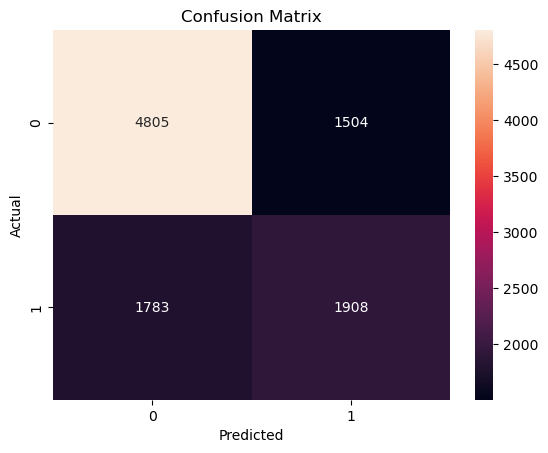

In [108]:
import matplotlib.pyplot as plt
import  seaborn as sns

cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [109]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

print("Random Forest Accuracy : ", accuracy_score(y_test,y_pred))

Random Forest Accuracy :  0.6713


In [110]:
results.append({
    "model": "Random Forest",
    "features": "TF-IDF only+word2vec",
    "accuracy": accuracy_score(y_test, y_pred_rf)
})

In [111]:
#feature importance

import numpy as np

importances = rf.feature_importances_

for i, col in enumerate(X.columns):
    print(col, ":", importances[i])

q1_len : 0.08384377705096123
q2_len : 0.08366469402795229
q1_words : 0.04622187234239279
q2_words : 0.04897312729109946
common_words : 0.055122867773990745
word_share : 0.13225729909650627
len_diff : 0.07519340578274018
fuzz_ratio : 0.1413478442451085
partial_ratio : 0.11082453649025392
tfidf_cosine_similarity : 0.0822650069560132
w2v_similarity : 0.1402855689429815


In [20]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.3/69.5 MB 16.6 MB/s eta 0:00:05
   --- ------------------------------------ 6.8/69.5 MB 26.2 MB/s eta 0:00:03
   ---- ----------------------------------- 7.9/69.5 MB 18.3 MB/s eta 0:00:04
   ----- ---------------------------------- 8.9/69.5 MB 13.3 MB/s eta 0:00:05
   ----- ---------------------------------- 10.0/69.5 MB 12.8 MB/s eta 0:00:05
   ------ --------------------------------- 12.1/69.5 MB 10.9 MB/s eta 0:00:06
   ------- -------------------------------- 13.1/69.5 MB 10.1 MB/s eta 0:00:06
   -------- ------------------------------- 14.4/69.5 MB 9.5 MB/s eta 0:00:06
   --------- ------------------------------ 15.7/69.5 MB 9.1 MB/s eta 0:00:06
   --------- ------------------------------ 16.8/69.5 MB 8.8 MB/s eta 0:00:06
   ---------- ----------------------------- 18.6/69.5 MB 8.5 MB/s eta

In [112]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [113]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [114]:
y_pred_xgb=xgb_model.predict(X_test)

print("XGBoost Accuracy: ",accuracy_score(y_test,y_pred_xgb))

print("\nClassification Report : \n")
print(classification_report(y_test,y_pred_xgb))

XGBoost Accuracy:  0.738

Classification Report : 

              precision    recall  f1-score   support

           0       0.81      0.77      0.79      6309
           1       0.63      0.69      0.66      3691

    accuracy                           0.74     10000
   macro avg       0.72      0.73      0.72     10000
weighted avg       0.74      0.74      0.74     10000



In [115]:
results.append({
    "model": "XGBoost",
    "features": "TF-IDF only+word2vec",
    "accuracy": accuracy_score(y_test, y_pred_xgb)
})

In [116]:
results_df=pd.DataFrame(results)

In [117]:
results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380


In [118]:
results_df.to_csv("model_results.csv", index=False)

In [ ]:
# accuracy has improved with word 2 vec

# here i have come after completing 4 th notebook with deep learning approches

# Model Saving

In [3]:
import pandas as pd

results_df = pd.read_csv('model_results.csv')

In [4]:
results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380
6,SimpleRnn,Deep Learning Approach,0.7202
7,LSTM,Deep Learning Approach,0.7118
8,BiLSTM,Deep Learning Approach,0.7334
9,Siamese,Dl approach,0.7279


we can see that XGBoost has highest accuracy so we will use it

In [8]:
from xgboost import XGBClassifier
#training on whole dataset
final_xgb=XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

final_xgb.fit(X,y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [9]:
#save model

import pickle

with open('../models/xgb_model.pkl','wb') as f:
    pickle.dump(final_xgb,f)

print("model saved")

model saved


NameError: name 'tfidf_vectorizer' is not defined